# Advanced Apex Project-2 (M.Sc. DS & AI)
# Week-2 Project Outline Notebook

| Field | Details |
|---|---|
| **Project Title** | Credit Risk & Loan Default Prediction for Retail Lending |
| **Problem Statement** | P1 (BFSI) - Credit Risk & Loan Default Prediction |
| **Student Name** | Sandeep Kumar |
| **Student ID** | 2025EM1200293 |
| **Program** | M.Sc. Data Science & Artificial Intelligence |
| **Cohort / Trimester** | Cohort-2 / Trimester-3 |
| **Submission** | Week-2 (Project Outline) |
| **Dataset** | German Credit Data - UCI Statlog (1,000 records) |

## 1. Problem Statement & Business Goal

Every time a bank sanctions a loan it is taking a bet on whether the borrower will pay it back. Getting that bet wrong is costly: lending to someone who later defaults means losing a large part of the principal, while refusing a customer who would have repaid means losing good interest income. Credit-risk scoring is the attempt to make that decision a little less blind.

The task here is to classify a loan applicant as a **good** credit (likely to repay) or a **bad** credit (likely to default) from their financial and personal profile - a binary classification problem.

One detail shapes the whole project: the German Credit dataset comes with a cost matrix in which labelling a genuinely *bad* customer as *good* is treated as **five times** more expensive than the reverse mistake. In other words, missing a defaulter hurts far more than being over-cautious with a good applicant. Because of that, and because the classes are imbalanced, **recall on the default class and ROC-AUC matter more than plain accuracy** - a model that simply predicts "good" for everyone would score 70% accuracy and still be useless.

## 2. Dataset Description

- **Source:** UCI Machine Learning Repository - *Statlog (German Credit Data)*, donated by Prof. Dr. Hans Hofmann, University of Hamburg (dataset id 144).
- **Access:** loaded with the official `ucimlrepo` package, exactly as shown on the dataset page.
- **Size:** 1,000 rows, 20 predictor attributes + 1 target.
- **Target:** originally coded `1 = Good`, `2 = Bad`; we remap to `0 = Good`, `1 = Bad (default)` so the positive class is the risk event.
- **Class balance:** 700 good vs 300 bad (about 70/30).
- **Feature mix:** 7 numerical + 13 categorical attributes. The categoricals are stored as symbolic codes (`A11`, `A34`, `A43`, ...).

### Data dictionary

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | status_checking_acct | categorical | Status of existing checking account |
| 2 | duration_months | numerical | Loan duration in months |
| 3 | credit_history | categorical | Past repayment history |
| 4 | purpose | categorical | Purpose of the loan |
| 5 | credit_amount | numerical | Credit amount (Deutsche Mark) |
| 6 | savings_acct | categorical | Savings account / bonds |
| 7 | employment_since | categorical | Present employment duration |
| 8 | installment_rate_pct | numerical | Installment rate as % of disposable income |
| 9 | personal_status_sex | categorical | Personal status and sex |
| 10 | other_debtors | categorical | Other debtors / guarantors |
| 11 | residence_since | numerical | Years at present residence |
| 12 | property | categorical | Property owned |
| 13 | age_years | numerical | Age in years |
| 14 | other_installment_plans | categorical | Other installment plans |
| 15 | housing | categorical | Housing (rent / own / free) |
| 16 | existing_credits | numerical | Number of existing credits at this bank |
| 17 | job | categorical | Job / skill level |
| 18 | num_dependents | numerical | People liable for maintenance |
| 19 | telephone | categorical | Telephone registered |
| 20 | foreign_worker | categorical | Foreign worker (yes / no) |
| - | **credit_risk** (target) | binary | 0 = Good, 1 = Bad (default) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Some networks/IDEs can't verify UCI's TLS certificate (OpenSSL 3 strict check /
# missing issuer), which blocks the ucimlrepo download. Relax verification so the
# public dataset loads consistently across environments.
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
ssl.create_default_context = lambda *a, **k: ssl._create_unverified_context()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Data Loading

The dataset is pulled straight from the UCI repository with the `ucimlrepo` helper (the method recommended on the dataset's own page). The attributes come back with placeholder names `Attribute1..Attribute20`, so we attach the documented column names. A small offline fallback to a bundled copy is included so the notebook still runs without a connection.

In [2]:
from ucimlrepo import fetch_ucirepo

# Documented names for the 20 attributes (from the UCI dataset description).
feature_names = [
    'status_checking_acct', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings_acct', 'employment_since', 'installment_rate_pct',
    'personal_status_sex', 'other_debtors', 'residence_since', 'property',
    'age_years', 'other_installment_plans', 'housing', 'existing_credits',
    'job', 'num_dependents', 'telephone', 'foreign_worker',
]

# Fallback copy of german.data hosted on Google Drive (direct-download link).
DATA_URL = 'https://drive.google.com/uc?export=download&id=1ZFP28NsDP5kjPaFjYp6yZUgrc4wDpv94'

try:
    german = fetch_ucirepo(id=144)               # Statlog (German Credit Data)
    X_raw = german.data.features.copy()
    y_raw = german.data.targets.copy()
    X_raw.columns = feature_names
    df = X_raw.copy()
    df['credit_risk'] = y_raw.iloc[:, 0].values
except Exception as err:
    print('UCI server unreachable (%s); loading the hosted copy instead.' % type(err).__name__)
    df = pd.read_csv(DATA_URL, sep=' ', header=None,
                     names=feature_names + ['credit_risk'])

# Remap target: 1 (Good) -> 0, 2 (Bad/default) -> 1  so positive class = default risk.
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1000, 21)


,status_checking_acct,duration_months,credit_history,purpose,credit_amount,savings_acct,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age_years,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## 4. Initial Data Inspection

A few quick checks before modelling: are there missing values or duplicates, are the dtypes sensible, and how balanced is the target?

In [3]:
print('Rows, Columns   :', df.shape)
print('Missing values  :', int(df.isnull().sum().sum()))
print('Duplicate rows  :', int(df.duplicated().sum()))
print('\nDtype counts:')
print(df.dtypes.value_counts())

counts = df['credit_risk'].value_counts().sort_index()
pct = (counts / len(df) * 100).round(1)
print('\nTarget distribution:')
dist = pd.DataFrame({'count': counts.values, 'percent': pct.values},
                    index=['0 = Good', '1 = Bad (default)'])
print(dist)

Rows, Columns   : (1000, 21)
Missing values  : 0
Duplicate rows  : 0

Dtype counts:
str      13
int64     8
Name: count, dtype: int64

Target distribution:
                   count  percent
0 = Good             700     70.0
1 = Bad (default)    300     30.0


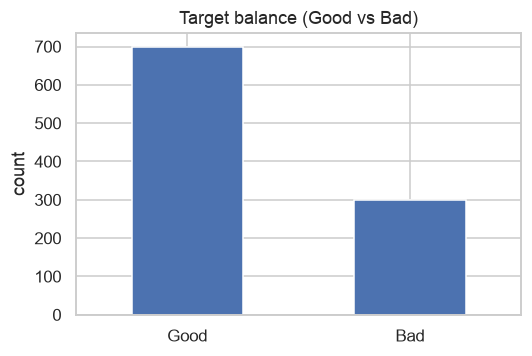

In [4]:
ax = (df['credit_risk'].map({0: 'Good', 1: 'Bad'})
        .value_counts().reindex(['Good', 'Bad']).plot(kind='bar', figsize=(5, 3.4)))
ax.set_title('Target balance (Good vs Bad)')
ax.set_xlabel(''); ax.set_ylabel('count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**What the inspection shows**

- The data is complete: no missing values and no duplicate rows, so preprocessing can focus on encoding and scaling rather than imputation.
- The target is imbalanced at roughly 70% good / 30% bad, which confirms that accuracy alone would be misleading and that recall on defaulters and ROC-AUC are the metrics to watch.

## 5. Baseline Model

For the baseline we go straight to a **Random Forest**, one of the models named for this problem statement. It gives a solid first result with very little tuning, copes naturally with the mix of categorical and numeric fields, and its bagged trees are a sensible starting point before we bring in the boosting methods in later weeks.

Everything sits inside a scikit-learn `Pipeline`: a `ColumnTransformer` one-hot-encodes the 13 categoricals and standard-scales the 7 numerics, and the classifier sits at the end. Building it this way means the encoders and scaler are fitted only on the training data, so no information leaks from the test set. The train/test split is stratified to keep the 70/30 balance in both parts.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

target = 'credit_risk'
X = df.drop(columns=[target])
y = df[target]

categorical = X.select_dtypes(exclude='number').columns.tolist()
numeric = X.select_dtypes(include='number').columns.tolist()
print(f'{len(categorical)} categorical, {len(numeric)} numeric features')

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numeric),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

baseline = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])
baseline.fit(X_train, y_train)
print('\nRandom Forest baseline trained.')

13 categorical, 7 numeric features
Train: (750, 20) | Test: (250, 20)



Random Forest baseline trained.


## 6. Evaluation Metrics

Given the 5:1 cost of missing a defaulter, we look beyond accuracy to precision, recall, F1 and ROC-AUC, and read the confusion matrix to see where the errors fall.

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

proba = baseline.predict_proba(X_test)[:, 1]
pred = baseline.predict(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, pred),
    'Precision': precision_score(y_test, pred),
    'Recall': recall_score(y_test, pred),
    'F1': f1_score(y_test, pred),
    'ROC-AUC': roc_auc_score(y_test, proba),
}
print('Random Forest baseline - test metrics')
for k, v in metrics.items():
    print(f'  {k:10s}: {v:.3f}')

print('\nClassification report:\n')
print(classification_report(y_test, pred, target_names=['Good', 'Bad']))

Random Forest baseline - test metrics
  Accuracy  : 0.752
  Precision : 0.633
  Recall    : 0.413
  F1        : 0.500
  ROC-AUC   : 0.802

Classification report:

              precision    recall  f1-score   support

        Good       0.78      0.90      0.84       175
         Bad       0.63      0.41      0.50        75

    accuracy                           0.75       250
   macro avg       0.71      0.66      0.67       250
weighted avg       0.74      0.75      0.73       250



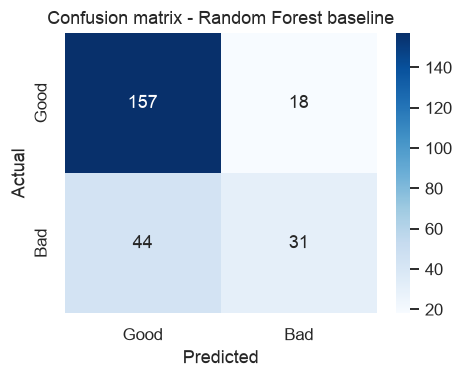

In [7]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4.4, 3.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.title('Confusion matrix - Random Forest baseline')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

**Reading the baseline**

- Overall accuracy sits comfortably above the 70% "predict-everyone-good" line, and ROC-AUC around 0.80 shows the model separates the two classes reasonably well even before any tuning.
- Recall on the *bad* class is the weak spot: at the default 0.5 threshold the model still misses a fair share of defaulters. That is expected on imbalanced data and is exactly what the next stages will target through class weighting, resampling and cost-aware threshold selection.

## 7. Proposed Workflow

The project follows the standard end-to-end pipeline:

```
Data Loading -> Data Preprocessing -> EDA -> Feature Engineering ->
Baseline Model -> Improved Model(s) -> Hyperparameter Tuning ->
Model Comparison -> Evaluation & Interpretation
```

Week-2 covers the left side of that chain: loading, inspection and a working Random Forest baseline with the right evaluation lens. Weeks 5 and 9 move to the right - deeper EDA, engineered features (for example an installment-burden ratio and age bands), the full ensemble family with imbalance handling, cross-validated tuning, and model interpretation.

## 8. Tuning Strategy (outline)

Tuning is planned rather than executed at this stage, but the approach is fixed. We will start with `RandomizedSearchCV` for a broad sweep, then refine the best region with `GridSearchCV`, all under **5-fold stratified cross-validation scored on ROC-AUC** so the imbalance is respected.

| Model | Key hyperparameters to search |
|-------|-------------------------------|
| Random Forest | n_estimators, max_depth, min_samples_leaf, max_features, class_weight |
| Gradient Boosting | n_estimators, learning_rate, max_depth, subsample |
| AdaBoost | n_estimators, learning_rate |
| XGBoost | n_estimators, learning_rate, max_depth, subsample, colsample_bytree, scale_pos_weight |
| LightGBM | n_estimators, learning_rate, num_leaves, min_child_samples, scale_pos_weight |

Alongside the search we will handle the class imbalance (class weights, `scale_pos_weight`, or SMOTE) and tune the decision threshold using the 5:1 cost matrix, rather than leaving it at 0.5.

## 9. Reproducibility & Environment

In [8]:
import sys, sklearn
print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('Pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('Random seed :', RANDOM_STATE)

Python      : 3.13.7
NumPy       : 2.5.3
Pandas      : 3.0.6
scikit-learn: 1.9.1
Random seed : 42


## 10. Conclusion (Week-2)

This outline establishes the foundation for the credit-risk project. The problem is framed as cost-sensitive binary classification where recall on defaulters and ROC-AUC lead the evaluation. The German Credit dataset is understood - 1,000 clean records, 20 mixed-type features, a 70/30 imbalance and a full data dictionary. A Random Forest baseline is built inside a leakage-safe pipeline and evaluated with the appropriate metrics, and a concrete tuning and improvement plan is laid out for Weeks 5 and 9.

## 11. References

1. Hofmann, H. *Statlog (German Credit Data)*, UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data
2. `ucimlrepo` package: https://github.com/uci-ml-repo/ucimlrepo
3. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825-2830.